In [1]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import os
import sys

parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
# MPC import
from LinearMPC_part_3.MPCVelControl import MPCVelControl
from PIControl.PIControl import PIControl
import numpy as np
from src.rocket import Rocket
from src.vel_rocket_vis import RocketVis, plot_static_states_inputs

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



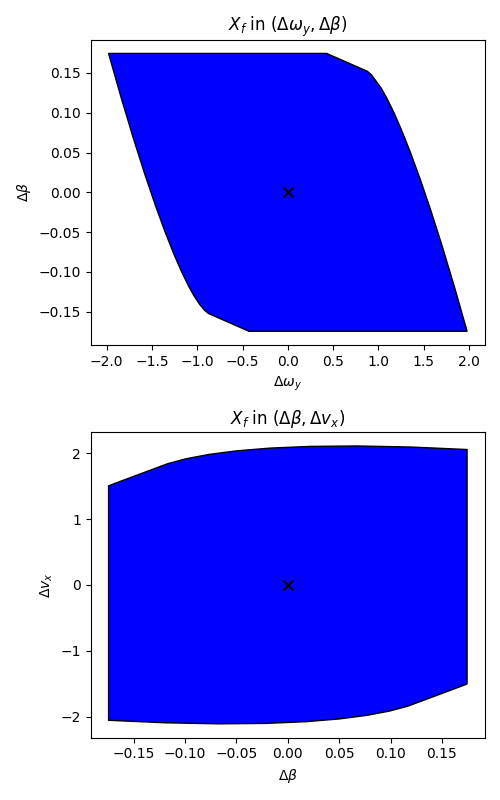

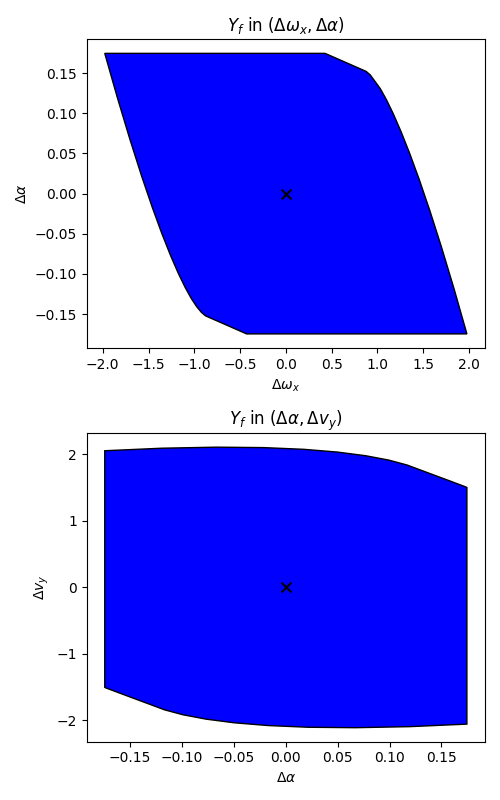

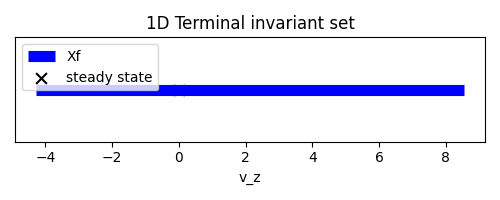

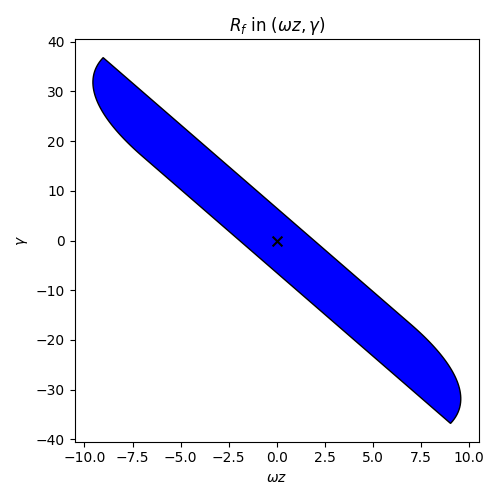

Simulating time 0.00: [0. 0. 0.]

Simulating time 0.05: [-0.85705188 -0.0214263   0.1248567 ]

Simulating time 0.10: [-1.71409809 -0.08570505  0.22870194]

Simulating time 0.15: [-0.8995892  -0.15104723  0.04701123]

Simulating time 0.20: [-0.04585057 -0.17468322 -0.16244796]


C:\Users\Aayushi Barve\AppData\Roaming\Python\Python312\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.25: [ 0.03921487 -0.17484912 -0.26104962]

 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.30: [-0.02271265 -0.17443656 -0.33727577]

Simulating time 0.35: [ 0.01008677 -0.17475221 -0.42785869]

 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.40: [-0.00121344 -0.17453037 -0.51176982]

Simulating time 0.45: [ 0.00190413 -0.17451311 -0.59781111]

Simulating time 0.50: [-0.00134672 -0.17449917 -0.68287796]

Simulating time 0.55: [ 0.00118234 -0.17450328 -0.76881984]

Simulating time 0.60: [-0.00117564 -0.17450311 -0.8540208 ]

Simulating time 0.65: [ 5.88291292e-04 -1.74517796e-01 -9.39851054e-01]

Simulating time 0.70: [-1.60086827e-04 -1.74507091e-01 -1.02530089e+00]

Simulating time 0.75: [ 4.32563129e-04 -1.74500279e-01 -1.11095002e+00]

Simulating time 0.80: [-5.11710389e-04 -1.74502258e-01 -1.196

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000001E2378463C0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000001E2378463C0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\asyncio\events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_cont

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=399, step=2), IntSlider(value=0…

In [3]:
Ts = 0.05
sim_time = 20
H = 5.0
x0 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 50, 50, 100])  # initial state
pos_target = np.array([0, 0, 10.0])

rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
pos_controller = PIControl(pos_target)
mpc = MPCVelControl().new_controller(rocket, Ts, H)

t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, ref = rocket.simulate_control(
    mpc, sim_time, H, x0, pos_control=pos_controller, method="linear"
)

vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(
    t_cl[:-1],
    x_cl[:, :-1],
    u_cl,
    Ref=ref[:, :-1],
    T_ol=t_ol[..., :-1],
    X_ol=x_ol,
    U_ol=u_ol,
);

In [8]:
t_ol, x_ol, u_ol, ref

print(t_ol.shape)
print(x_ol.shape)
print(u_ol.shape)
print(t_cl.shape)
print(x_cl.shape)
print(u_cl.shape)


(101, 401)
(12, 101, 401)
(4, 100, 400)
(401,)
(12, 401)
(4, 400)


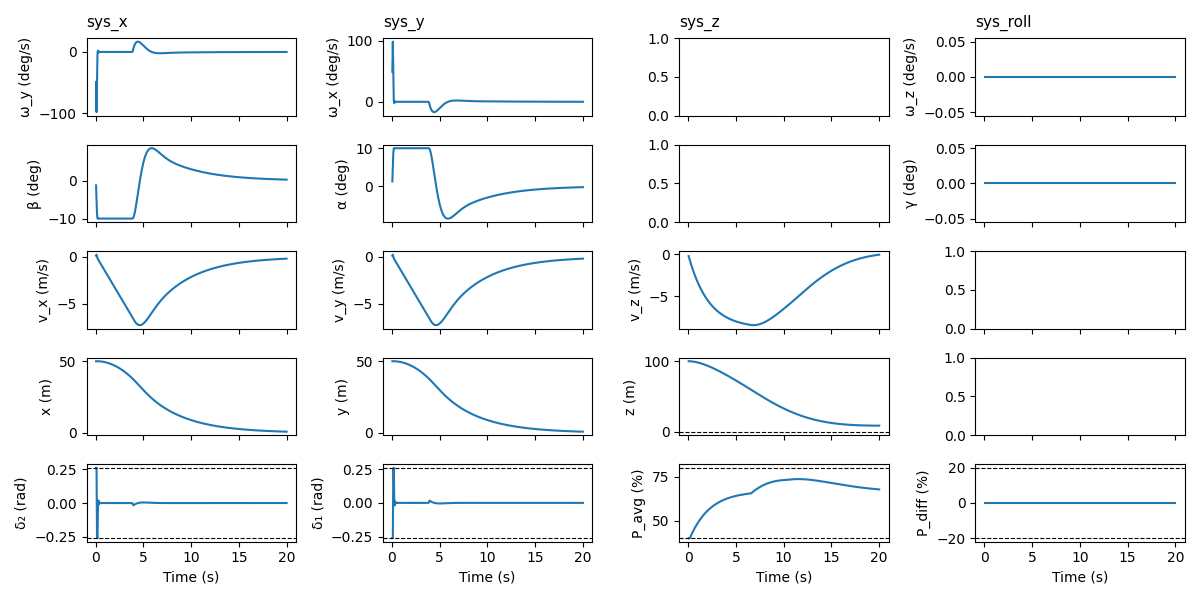

In [4]:
plot_static_states_inputs(t_cl[1:],x_cl[:,1:],u_cl)